Dataset link : https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database

**STep1: Basic setup**

In [27]:
# Install required libraries
!pip install pandas numpy matplotlib seaborn scikit-learn -q

# Import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, roc_curve)
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [28]:
# Auto load from GitHub — No manual upload needed!
GITHUB_RAW_URL = "https://raw.githubusercontent.com/just-abir/AI_ML_Lab_3/main/KNN_Model/Dataset/diabetes.csv"

df = pd.read_csv(GITHUB_RAW_URL)

print("✅ Dataset loaded automatically from GitHub!")
print(f"📐 Shape: {df.shape}")
print(f"\n🔍 First 5 rows:")
df.head()

✅ Dataset loaded automatically from GitHub!
📐 Shape: (768, 9)

🔍 First 5 rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [29]:
print("📋 Column Names:")
print(df.columns.tolist())

print("\n📊 Dataset Info:")
print(df.info())

print("\n📈 Basic Statistics:")
print(df.describe())

print("\n🎯 Target Value Counts:")
print(df['Outcome'].value_counts())
print("\n0 = Non-Diabetic")
print("1 = Diabetic")

📋 Column Names:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

📊 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None

📈 Basic Statistics:
       Pregnancies     Glucose  BloodPressure  SkinThick

Class Distribution Plot

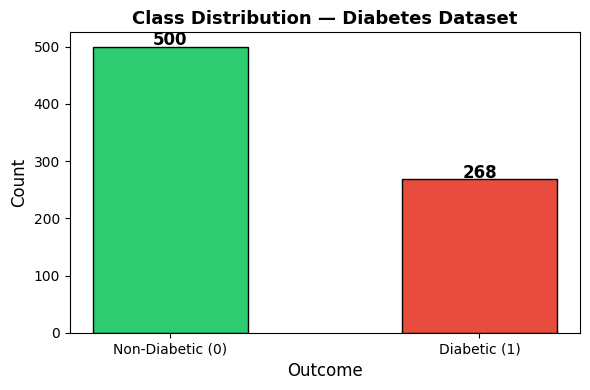

✅ Class Distribution Plot saved!


In [30]:
plt.figure(figsize=(6, 4))
colors = ['#2ecc71', '#e74c3c']
labels = ['Non-Diabetic (0)', 'Diabetic (1)']
counts = df['Outcome'].value_counts()

bars = plt.bar(labels, counts.values,
               color=colors,
               edgecolor='black',
               width=0.5)

plt.title('Class Distribution — Diabetes Dataset',
          fontsize=13, fontweight='bold')
plt.xlabel('Outcome', fontsize=12)
plt.ylabel('Count', fontsize=12)

for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 3,
             str(val),
             ha='center',
             fontsize=12,
             fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()
print("✅ Class Distribution Plot saved!")

**step2: Data Preprocessing**

In [31]:
print("🔍 Missing Values Check:")
print(df.isnull().sum())
print(f"\n✅ Total NaN missing values: {df.isnull().sum().sum()}")

# Diabetes dataset এ 0 values actually missing values!
# These columns cannot have 0 as valid value
zero_check_cols = ['Glucose', 'BloodPressure', 'SkinThickness',
                   'Insulin', 'BMI']

print("\n⚠️  Zero Value Check (Biologically Impossible Zeros):")
for col in zero_check_cols:
    zero_count = (df[col] == 0).sum()
    print(f"   {col:20s} : {zero_count} zeros")

🔍 Missing Values Check:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

✅ Total NaN missing values: 0

⚠️  Zero Value Check (Biologically Impossible Zeros):
   Glucose              : 5 zeros
   BloodPressure        : 35 zeros
   SkinThickness        : 227 zeros
   Insulin              : 374 zeros
   BMI                  : 11 zeros


Handle Missing Values (Replace 0 with Median)

In [32]:
# Replace 0s with median for biologically impossible columns
for col in zero_check_cols:
    median_val = df[col].median()
    df[col] = df[col].replace(0, median_val)
    print(f"✅ {col:20s} → 0s replaced with median ({median_val:.2f})")

print("\n✅ All missing/zero values handled!")
print("\n🔍 Verify — Zero Value Check After Fix:")
for col in zero_check_cols:
    zero_count = (df[col] == 0).sum()
    print(f"   {col:20s} : {zero_count} zeros remaining")

✅ Glucose              → 0s replaced with median (117.00)
✅ BloodPressure        → 0s replaced with median (72.00)
✅ SkinThickness        → 0s replaced with median (23.00)
✅ Insulin              → 0s replaced with median (30.50)
✅ BMI                  → 0s replaced with median (32.00)

✅ All missing/zero values handled!

🔍 Verify — Zero Value Check After Fix:
   Glucose              : 0 zeros remaining
   BloodPressure        : 0 zeros remaining
   SkinThickness        : 0 zeros remaining
   Insulin              : 0 zeros remaining
   BMI                  : 0 zeros remaining


eparate Features & Target

In [33]:
# Features and Target
X = df.drop(columns=['Outcome'])
y = df['Outcome']

print("✅ Features & Target separated!")
print(f"\n📐 Features (X) shape : {X.shape}")
print(f"📐 Target  (y) shape : {y.shape}")
print(f"\n📋 Feature columns:")
for i, col in enumerate(X.columns, 1):
    print(f"   {i}. {col}")

✅ Features & Target separated!

📐 Features (X) shape : (768, 8)
📐 Target  (y) shape : (768,)

📋 Feature columns:
   1. Pregnancies
   2. Glucose
   3. BloodPressure
   4. SkinThickness
   5. Insulin
   6. BMI
   7. DiabetesPedigreeFunction
   8. Age


 Train / Validation / Test Split

In [34]:
# First split: 80% train+val, 20% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Second split: 75% train, 25% validation (from 80%)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.25,
    random_state=42,
    stratify=y_temp
)

print("✅ Data Split Completed!")
print(f"\n📊 Split Summary:")
print(f"   🔵 Training   set : {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"   🟡 Validation set : {X_val.shape[0]} samples ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"   🔴 Test       set : {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

✅ Data Split Completed!

📊 Split Summary:
   🔵 Training   set : 460 samples (59.9%)
   🟡 Validation set : 154 samples (20.1%)
   🔴 Test       set : 154 samples (20.1%)


Normalize / Standardize Feature

In [35]:
# StandardScaler — Important for KNN (distance-based)
scaler = StandardScaler()

# Fit ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print("✅ Feature Scaling (StandardScaler) applied!")
print("\n📊 After Scaling Stats (Train):")
print(f"   Mean : {X_train_scaled.mean():.6f}  (should be ≈ 0)")
print(f"   Std  : {X_train_scaled.std():.6f}   (should be ≈ 1)")

print("\n⚠️  Why Scaling is Critical for KNN?")
print("   KNN uses distance (Euclidean/Manhattan)")
print("   Large scale features dominate distance")
print("   Scaling makes all features equally important ✅")

✅ Feature Scaling (StandardScaler) applied!

📊 After Scaling Stats (Train):
   Mean : 0.000000  (should be ≈ 0)
   Std  : 1.000000   (should be ≈ 1)

⚠️  Why Scaling is Critical for KNN?
   KNN uses distance (Euclidean/Manhattan)
   Large scale features dominate distance
   Scaling makes all features equally important ✅


Preprocessing Summary Heatmap

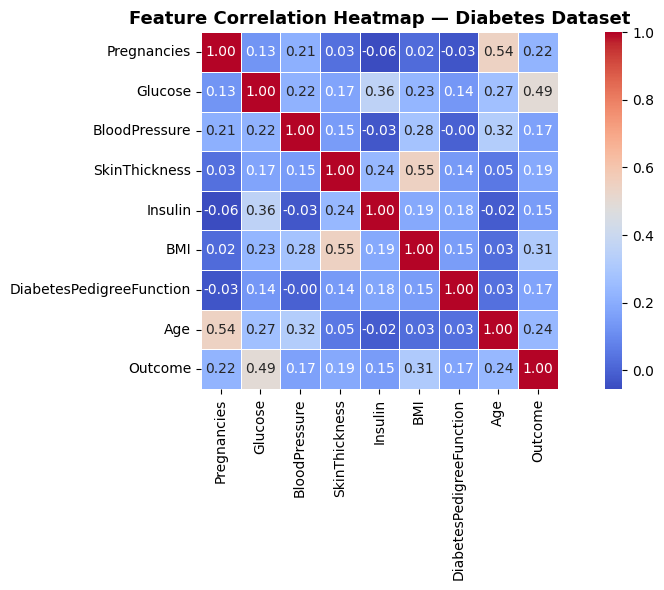

✅ Correlation Heatmap saved!


In [36]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(),
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            linewidths=0.5,
            square=True)

plt.title('Feature Correlation Heatmap — Diabetes Dataset',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()
print("✅ Correlation Heatmap saved!")

**Step 3: KNN Model Training + Hyperparameter Tuning**

 Elbow Method (Find Best K)

In [37]:
# Test k values from 1 to 30
k_range = range(1, 31)
error_rates = []
accuracies = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    val_pred = knn.predict(X_val_scaled)
    error_rates.append(1 - accuracy_score(y_val, val_pred))
    accuracies.append(accuracy_score(y_val, val_pred))

best_k = k_range[np.argmin(error_rates)]
print(f"✅ Elbow Method Completed!")
print(f"🏆 Best K value : {best_k}")
print(f"🎯 Best Accuracy: {max(accuracies)*100:.2f}%")

✅ Elbow Method Completed!
🏆 Best K value : 26
🎯 Best Accuracy: 81.82%


Elbow Method Plot

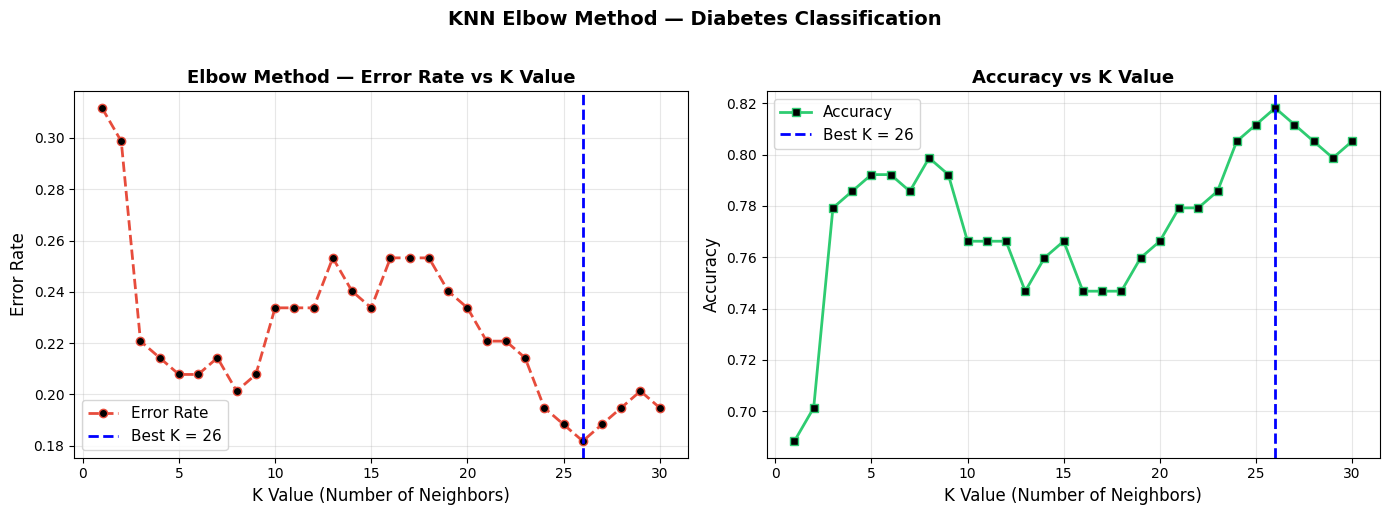

✅ Elbow Method Plot saved!


In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Error Rate vs K ---
axes[0].plot(k_range, error_rates,
             color='#e74c3c',
             linestyle='--',
             marker='o',
             markerfacecolor='black',
             markersize=6,
             linewidth=2,
             label='Error Rate')

axes[0].axvline(x=best_k,
                color='blue',
                linestyle='--',
                linewidth=2,
                label=f'Best K = {best_k}')

axes[0].set_title('Elbow Method — Error Rate vs K Value',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('K Value (Number of Neighbors)', fontsize=12)
axes[0].set_ylabel('Error Rate', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)

# --- Right: Accuracy vs K ---
axes[1].plot(k_range, accuracies,
             color='#2ecc71',
             linestyle='-',
             marker='s',
             markerfacecolor='black',
             markersize=6,
             linewidth=2,
             label='Accuracy')

axes[1].axvline(x=best_k,
                color='blue',
                linestyle='--',
                linewidth=2,
                label=f'Best K = {best_k}')

axes[1].set_title('Accuracy vs K Value',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('K Value (Number of Neighbors)', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)

plt.suptitle('KNN Elbow Method — Diabetes Classification',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('elbow_method.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Elbow Method Plot saved!")

Hyperparameter Tunning (GridSearchCV)

In [39]:
# Define parameter grid
param_grid = {
    'n_neighbors' : list(range(1, 31)),
    'weights'     : ['uniform', 'distance'],
    'metric'      : ['euclidean', 'manhattan', 'minkowski']
}

print("🔍 Starting Hyperparameter Tuning...")
print("⏳ Please wait 1-2 minutes...\n")

grid_search = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print("\n✅ Hyperparameter Tuning Completed!")
print(f"\n🏆 Best Parameters:")
print(f"   K (neighbors) : {grid_search.best_params_['n_neighbors']}")
print(f"   Weights       : {grid_search.best_params_['weights']}")
print(f"   Metric        : {grid_search.best_params_['metric']}")
print(f"\n🎯 Best CV Accuracy: {grid_search.best_score_*100:.2f}%")

🔍 Starting Hyperparameter Tuning...
⏳ Please wait 1-2 minutes...

Fitting 5 folds for each of 180 candidates, totalling 900 fits

✅ Hyperparameter Tuning Completed!

🏆 Best Parameters:
   K (neighbors) : 19
   Weights       : uniform
   Metric        : euclidean

🎯 Best CV Accuracy: 76.52%


Train Final KNN Model

In [40]:
# Use best model from GridSearch
best_knn = grid_search.best_estimator_

# Predictions on all sets
train_pred = best_knn.predict(X_train_scaled)
val_pred   = best_knn.predict(X_val_scaled)
test_pred  = best_knn.predict(X_test_scaled)

train_acc  = accuracy_score(y_train, train_pred)
val_acc    = accuracy_score(y_val,   val_pred)
test_acc   = accuracy_score(y_test,  test_pred)

print("✅ Final KNN Model Ready!")
print(f"\n📊 Accuracy Summary:")
print(f"   🔵 Training   Accuracy : {train_acc*100:.2f}%")
print(f"   🟡 Validation Accuracy : {val_acc*100:.2f}%")
print(f"   🔴 Test       Accuracy : {test_acc*100:.2f}%")

print(f"\n⚙️  Best Model Configuration:")
print(f"   K (neighbors) : {grid_search.best_params_['n_neighbors']}")
print(f"   Weights       : {grid_search.best_params_['weights']}")
print(f"   Metric        : {grid_search.best_params_['metric']}")

✅ Final KNN Model Ready!

📊 Accuracy Summary:
   🔵 Training   Accuracy : 79.78%
   🟡 Validation Accuracy : 75.97%
   🔴 Test       Accuracy : 75.97%

⚙️  Best Model Configuration:
   K (neighbors) : 19
   Weights       : uniform
   Metric        : euclidean


Cross Validation Score

✅ Cross Validation Results:

📊 CV Scores per Fold:
   Fold 1 : 78.26%
   Fold 2 : 76.09%
   Fold 3 : 72.83%
   Fold 4 : 76.09%
   Fold 5 : 79.35%

🎯 Mean CV Accuracy : 76.52%
📉 Std Deviation    : 2.24%


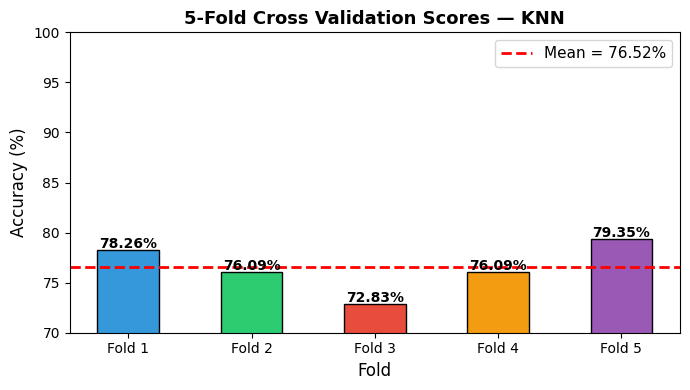

✅ Cross Validation Plot saved!


In [41]:
# 5-Fold Cross Validation on best model
cv_scores = cross_val_score(
    best_knn,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='accuracy'
)

print("✅ Cross Validation Results:")
print(f"\n📊 CV Scores per Fold:")
for i, score in enumerate(cv_scores, 1):
    print(f"   Fold {i} : {score*100:.2f}%")

print(f"\n🎯 Mean CV Accuracy : {cv_scores.mean()*100:.2f}%")
print(f"📉 Std Deviation    : {cv_scores.std()*100:.2f}%")

# Plot CV scores
plt.figure(figsize=(7, 4))
bars = plt.bar([f'Fold {i}' for i in range(1, 6)],
               cv_scores * 100,
               color=['#3498db', '#2ecc71', '#e74c3c',
                      '#f39c12', '#9b59b6'],
               edgecolor='black',
               width=0.5)

plt.axhline(y=cv_scores.mean()*100,
            color='red',
            linestyle='--',
            linewidth=2,
            label=f'Mean = {cv_scores.mean()*100:.2f}%')

for bar, val in zip(bars, cv_scores):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.2,
             f'{val*100:.2f}%',
             ha='center',
             fontsize=10,
             fontweight='bold')

plt.title('5-Fold Cross Validation Scores — KNN',
          fontsize=13, fontweight='bold')
plt.xlabel('Fold', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.ylim([70, 100])
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('cross_validation.png', dpi=150)
plt.show()
print("✅ Cross Validation Plot saved!")

**Step 4: Evaluation & All Required Plots**

All evaluation Metrics

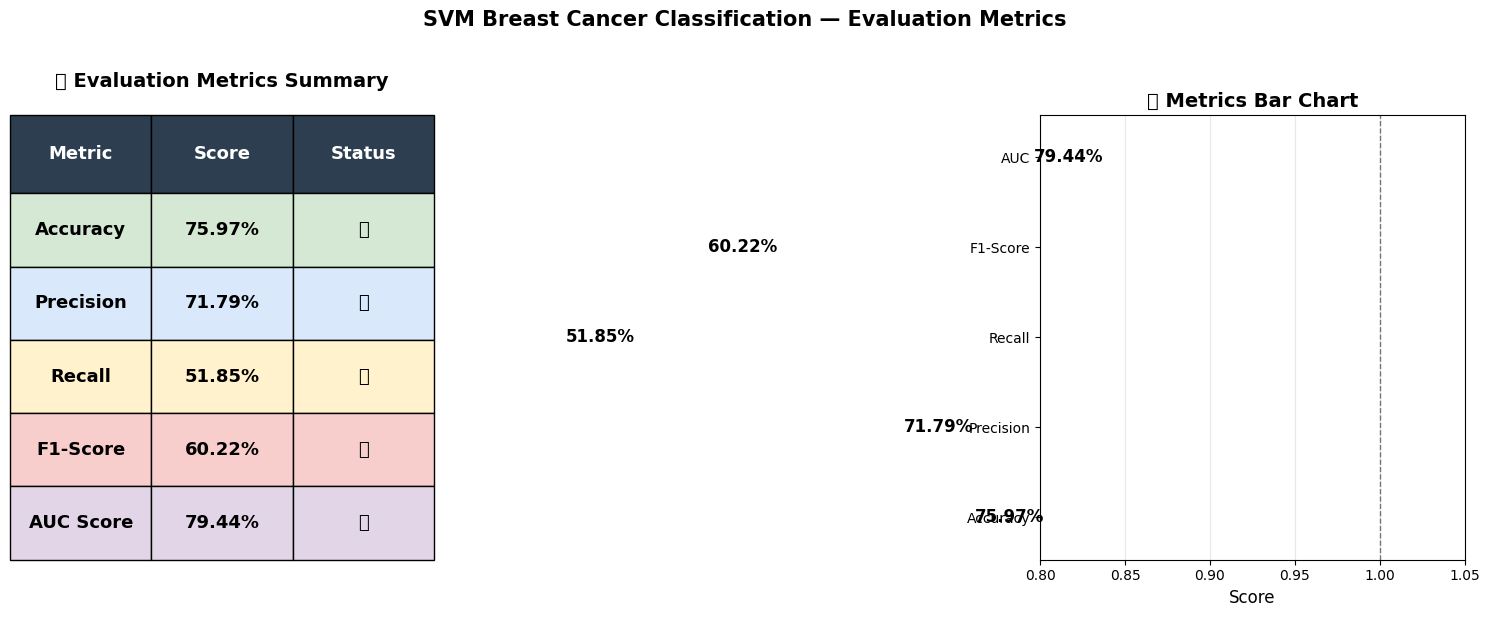

✅ Evaluation Metrics Plot saved!


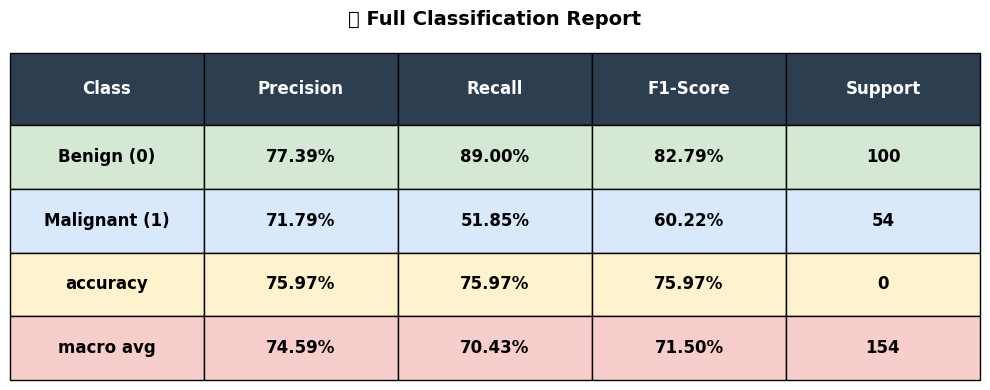

✅ Classification Report Table saved!


In [42]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, classification_report)

# Get predictions & probabilities
test_pred = best_knn.predict(X_test_scaled)
test_prob = best_knn.predict_proba(X_test_scaled)[:, 1]

# Calculate all metrics
accuracy  = accuracy_score(y_test, test_pred)
precision = precision_score(y_test, test_pred)
recall    = recall_score(y_test, test_pred)
f1        = f1_score(y_test, test_pred)
auc       = roc_auc_score(y_test, test_prob)

# ============================================
# PLOT 1 — Metrics Summary Visual Table
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Left: Metrics Table as Image ---
metrics_data = [
    ['Accuracy',  f'{accuracy*100:.2f}%',  '✅'],
    ['Precision', f'{precision*100:.2f}%', '✅'],
    ['Recall',    f'{recall*100:.2f}%',    '✅'],
    ['F1-Score',  f'{f1*100:.2f}%',        '✅'],
    ['AUC Score', f'{auc*100:.2f}%',       '✅'],
]

axes[0].axis('off')
table = axes[0].table(
    cellText=metrics_data,
    colLabels=['Metric', 'Score', 'Status'],
    cellLoc='center',
    loc='center',
    bbox=[0, 0, 1, 1]
)

# Style the table
table.auto_set_font_size(False)
table.set_fontsize(13)

# Header style
for j in range(3):
    table[0, j].set_facecolor('#2c3e50')
    table[0, j].set_text_props(color='white',
                                fontweight='bold',
                                fontsize=13)
    table[0, j].set_height(0.15)

# Row colors
row_colors = ['#d5e8d4', '#dae8fc', '#fff2cc', '#f8cecc', '#e1d5e7']
for i in range(1, 6):
    for j in range(3):
        table[i, j].set_facecolor(row_colors[i-1])
        table[i, j].set_text_props(fontsize=13, fontweight='bold')
        table[i, j].set_height(0.14)

axes[0].set_title('📊 Evaluation Metrics Summary',
                  fontsize=14, fontweight='bold', pad=20)

# --- Right: Metrics Bar Chart ---
metrics_names  = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']
metrics_values = [accuracy, precision, recall, f1, auc]
bar_colors     = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']

bars = axes[1].barh(metrics_names,
                    metrics_values,
                    color=bar_colors,
                    edgecolor='black',
                    height=0.5)

axes[1].set_xlim([0.8, 1.05])
axes[1].set_title('📊 Metrics Bar Chart',
                  fontsize=14, fontweight='bold')
axes[1].set_xlabel('Score', fontsize=12)
axes[1].axvline(x=1.0,
                color='black',
                linestyle='--',
                linewidth=1,
                alpha=0.5)
axes[1].grid(alpha=0.3, axis='x')

# Add value labels on bars
for bar, val in zip(bars, metrics_values):
    axes[1].text(bar.get_width() + 0.002,
                 bar.get_y() + bar.get_height()/2,
                 f'{val*100:.2f}%',
                 va='center',
                 fontsize=12,
                 fontweight='bold')

plt.suptitle('SVM Breast Cancer Classification — Evaluation Metrics',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('evaluation_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Evaluation Metrics Plot saved!")

# ============================================
# PLOT 2 — Full Classification Report Table
# ============================================
report = classification_report(y_test, test_pred,
         target_names=['Benign (0)', 'Malignant (1)'],
         output_dict=True)

report_df = pd.DataFrame(report).transpose().round(4)
report_df = report_df.iloc[:-1]  # Remove last row

fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')

report_data = []
headers = ['Class', 'Precision', 'Recall', 'F1-Score', 'Support']

for idx, row in report_df.iterrows():
    report_data.append([
        idx,
        f"{row['precision']*100:.2f}%",
        f"{row['recall']*100:.2f}%",
        f"{row['f1-score']*100:.2f}%",
        f"{int(row['support'])}"
    ])

table2 = ax.table(
    cellText=report_data,
    colLabels=headers,
    cellLoc='center',
    loc='center',
    bbox=[0, 0, 1, 1]
)

table2.auto_set_font_size(False)
table2.set_fontsize(12)

# Header style
for j in range(5):
    table2[0, j].set_facecolor('#2c3e50')
    table2[0, j].set_text_props(color='white',
                                 fontweight='bold',
                                 fontsize=12)
    table2[0, j].set_height(0.25)

# Row styles
row_colors2 = ['#d5e8d4', '#dae8fc', '#fff2cc', '#f8cecc']
for i in range(1, len(report_data)+1):
    for j in range(5):
        table2[i, j].set_facecolor(row_colors2[i-1])
        table2[i, j].set_text_props(fontsize=12, fontweight='bold')
        table2[i, j].set_height(0.22)

ax.set_title('📋 Full Classification Report',
             fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('classification_report.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Classification Report Table saved!")

Confusion Matrix

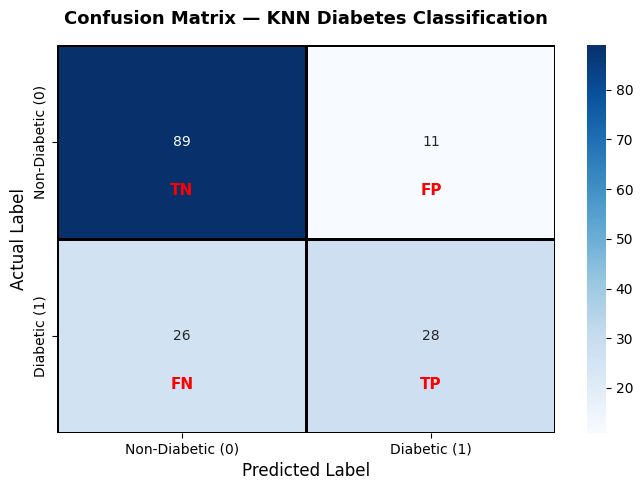

✅ Confusion Matrix saved!


In [43]:
cm = confusion_matrix(y_test, test_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            linewidths=1,
            linecolor='black',
            xticklabels=['Non-Diabetic (0)', 'Diabetic (1)'],
            yticklabels=['Non-Diabetic (0)', 'Diabetic (1)'])

plt.title('Confusion Matrix — KNN Diabetes Classification',
          fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)

# Add TN, FP, FN, TP labels
labels = [['TN', 'FP'], ['FN', 'TP']]
for i in range(2):
    for j in range(2):
        plt.text(j + 0.5, i + 0.75,
                 labels[i][j],
                 ha='center',
                 va='center',
                 fontsize=11,
                 color='red',
                 fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print("✅ Confusion Matrix saved!")

ROC Curver

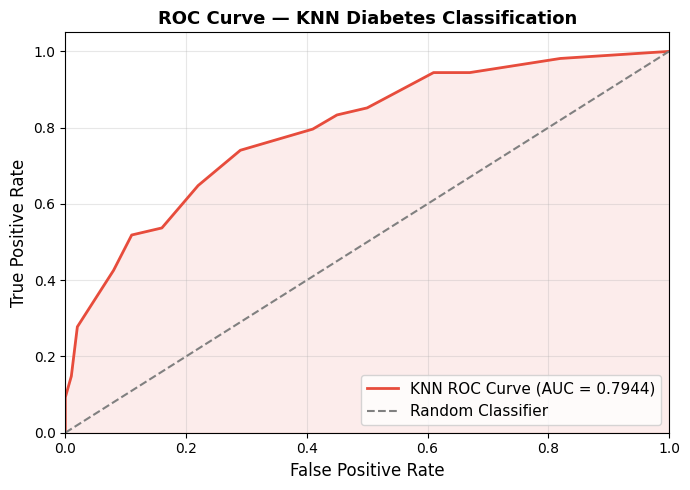

✅ ROC Curve saved!


In [44]:
fpr, tpr, thresholds = roc_curve(y_test, test_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr,
         color='#e74c3c',
         lw=2,
         label=f'KNN ROC Curve (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1],
         color='gray',
         linestyle='--',
         lw=1.5,
         label='Random Classifier')

plt.fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve — KNN Diabetes Classification',
          fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()
print("✅ ROC Curve saved!")

Sample predection

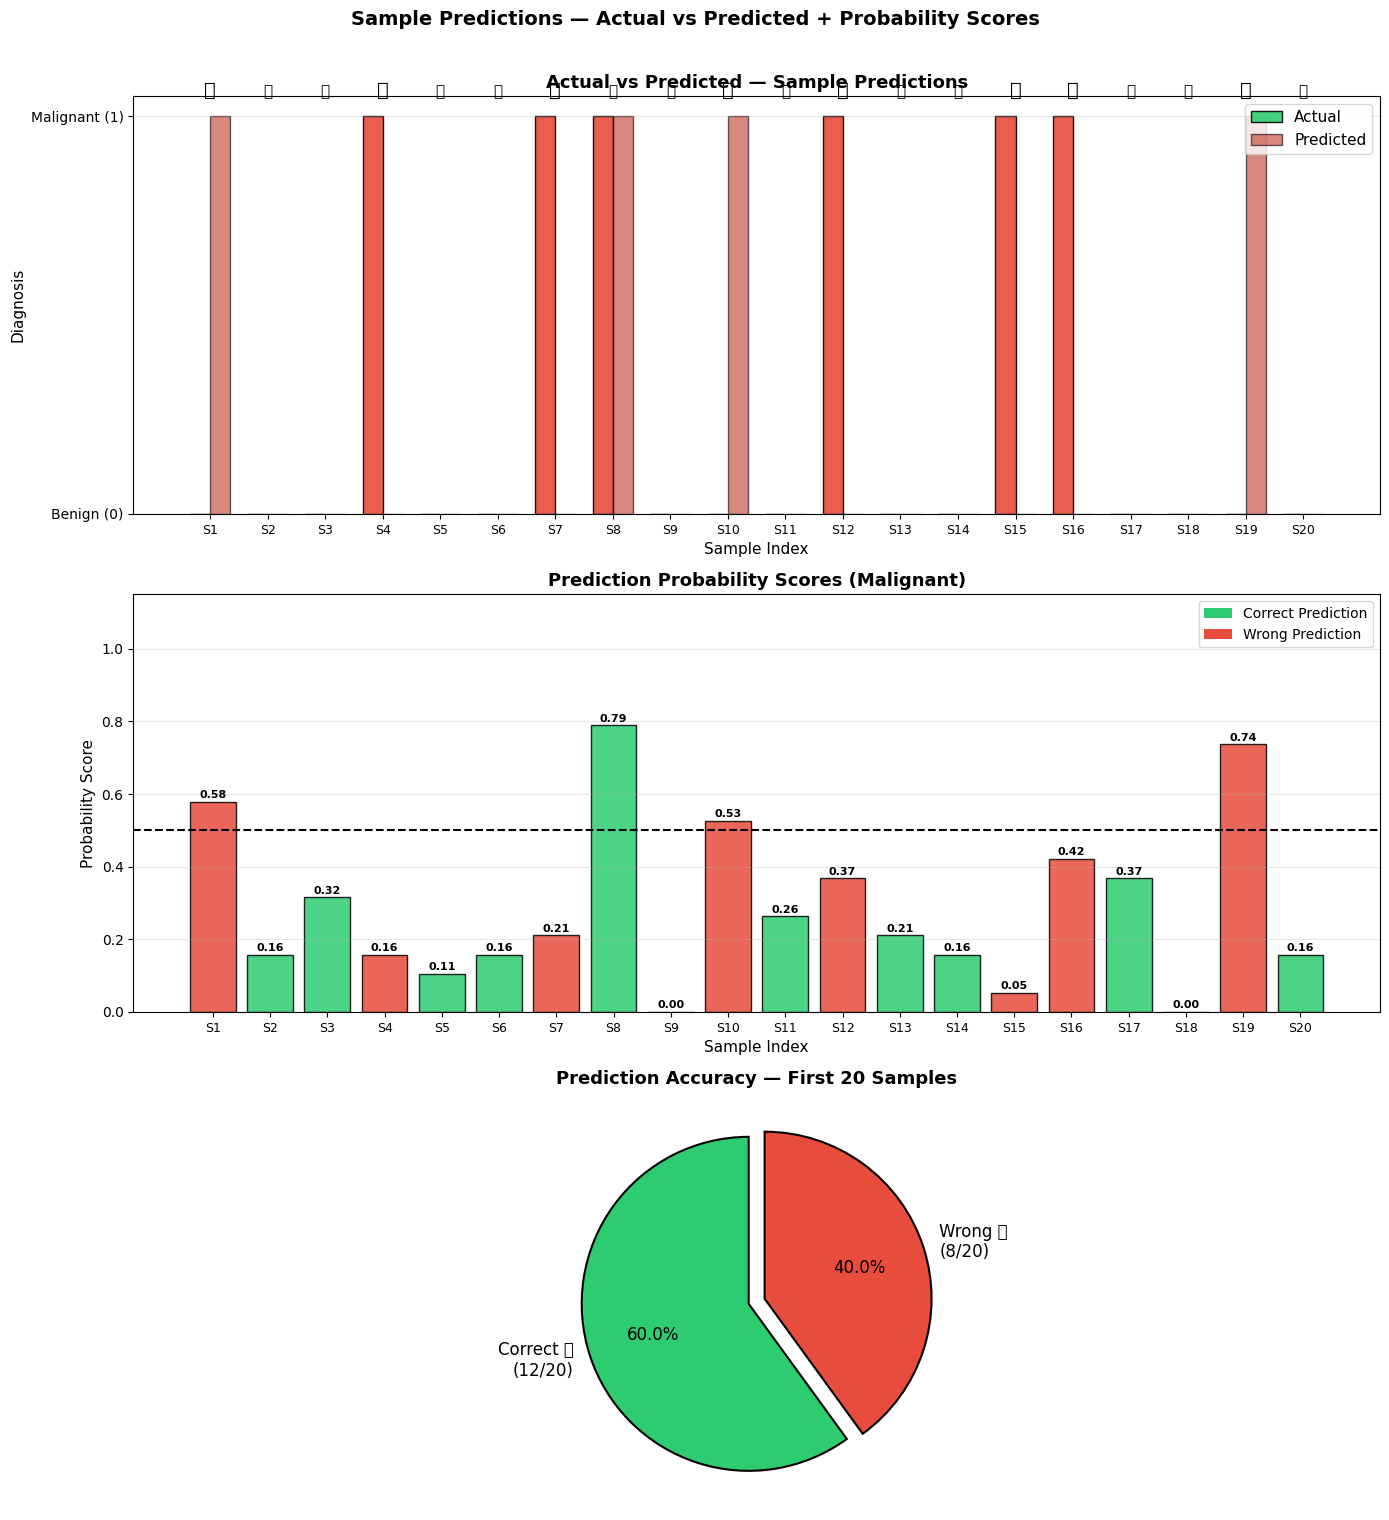

✅ Sample Prediction Plot saved!

📊 Summary:
   ✅ Correct : 12 / 20
   ❌ Wrong   : 8 / 20
   🎯 Accuracy: 60.0%


In [45]:
# Get predictions & probabilities
sample_size = 20
sample_actual    = y_test.values[:sample_size]
sample_predicted = test_pred[:sample_size]
sample_prob      = test_prob[:sample_size]

# Create dataframe
sample_df = pd.DataFrame({
    'Index'           : range(1, sample_size + 1),
    'Actual'          : sample_actual,
    'Predicted'       : sample_predicted,
    'Prob_Malignant'  : sample_prob.round(4),
    'Prob_Benign'     : (1 - sample_prob).round(4),
    'Correct'         : [True if a == p else False
                         for a, p in zip(sample_actual, sample_predicted)]
})

# ============================================
# PLOT 1 — Actual vs Predicted Bar Chart
# ============================================
fig, axes = plt.subplots(3, 1, figsize=(14, 15))

x = np.arange(sample_size)
width = 0.35

# Color mapping
actual_colors    = ['#2ecc71' if v == 0 else '#e74c3c'
                    for v in sample_actual]
predicted_colors = ['#27ae60' if v == 0 else '#c0392b'
                    for v in sample_predicted]

bars1 = axes[0].bar(x - width/2, sample_actual,
                    width,
                    color=actual_colors,
                    edgecolor='black',
                    label='Actual',
                    alpha=0.9)

bars2 = axes[0].bar(x + width/2, sample_predicted,
                    width,
                    color=predicted_colors,
                    edgecolor='black',
                    label='Predicted',
                    alpha=0.6)

# Mark wrong predictions
for i, correct in enumerate(sample_df['Correct']):
    if not correct:
        axes[0].annotate('❌',
                        xy=(i, 1.05),
                        ha='center',
                        fontsize=14)
    else:
        axes[0].annotate('✅',
                        xy=(i, 1.05),
                        ha='center',
                        fontsize=11)

axes[0].set_xticks(x)
axes[0].set_xticklabels([f'S{i}' for i in range(1, sample_size+1)],
                         fontsize=9)
axes[0].set_yticks([0, 1])
axes[0].set_yticklabels(['Benign (0)', 'Malignant (1)'], fontsize=10)
axes[0].set_title('Actual vs Predicted — Sample Predictions',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Sample Index', fontsize=11)
axes[0].set_ylabel('Diagnosis', fontsize=11)
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3, axis='y')

# ============================================
# PLOT 2 — Probability Bar Chart
# ============================================
prob_colors = ['#2ecc71' if c else '#e74c3c'
               for c in sample_df['Correct']]

bars3 = axes[1].bar(x, sample_prob,
                    color=prob_colors,
                    edgecolor='black',
                    alpha=0.85,
                    label='Prob (Malignant)')

axes[1].axhline(y=0.5,
                color='black',
                linestyle='--',
                linewidth=1.5,
                label='Decision Threshold (0.5)')

# Add probability values on bars
for bar, val in zip(bars3, sample_prob):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f'{val:.2f}',
                 ha='center',
                 fontsize=8,
                 fontweight='bold')

axes[1].set_xticks(x)
axes[1].set_xticklabels([f'S{i}' for i in range(1, sample_size+1)],
                         fontsize=9)
axes[1].set_ylim([0, 1.15])
axes[1].set_title('Prediction Probability Scores (Malignant)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Sample Index', fontsize=11)
axes[1].set_ylabel('Probability Score', fontsize=11)
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3, axis='y')

# Add correct/wrong color legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='Correct Prediction'),
    Patch(facecolor='#e74c3c', label='Wrong Prediction')
]
axes[1].legend(handles=legend_elements, fontsize=10, loc='upper right')

# ============================================
# PLOT 3 — Correct vs Wrong Pie Chart
# ============================================
correct_count = sample_df['Correct'].sum()
wrong_count   = sample_size - correct_count

pie_colors  = ['#2ecc71', '#e74c3c']
pie_labels  = [f'Correct ✅\n({correct_count}/{sample_size})',
               f'Wrong ❌\n({wrong_count}/{sample_size})']
pie_explode = (0.05, 0.05)

axes[2].pie([correct_count, wrong_count],
            labels=pie_labels,
            colors=pie_colors,
            explode=pie_explode,
            autopct='%1.1f%%',
            startangle=90,
            textprops={'fontsize': 12},
            wedgeprops={'edgecolor': 'black', 'linewidth': 1.5})

axes[2].set_title(f'Prediction Accuracy — First {sample_size} Samples',
                  fontsize=13, fontweight='bold')

plt.suptitle('Sample Predictions — Actual vs Predicted + Probability Scores',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('sample_predictions_plot.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Sample Prediction Plot saved!")
print(f"\n📊 Summary:")
print(f"   ✅ Correct : {correct_count} / {sample_size}")
print(f"   ❌ Wrong   : {wrong_count} / {sample_size}")
print(f"   🎯 Accuracy: {correct_count/sample_size*100:.1f}%")

 2D Decision Boundary Plot

In [ ]:
# Reduce to 2D using PCA
pca = PCA(n_components=2, random_state=42)
X_train_2d = pca.fit_transform(X_train_scaled)
X_test_2d  = pca.transform(X_test_scaled)

# Train KNN on 2D data
knn_2d = KNeighborsClassifier(
    n_neighbors=grid_search.best_params_['n_neighbors'],
    weights=grid_search.best_params_['weights'],
    metric=grid_search.best_params_['metric']
)
knn_2d.fit(X_train_2d, y_train)

# Create mesh grid
x_min = X_test_2d[:, 0].min() - 1
x_max = X_test_2d[:, 0].max() + 1
y_min = X_test_2d[:, 1].min() - 1
y_max = X_test_2d[:, 1].max() + 1

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                      np.linspace(y_min, y_max, 300))

# Predict on mesh
Z = knn_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot
plt.figure(figsize=(9, 6))
plt.contourf(xx, yy, Z,
             alpha=0.3,
             colors=['#2ecc71', '#e74c3c'])
plt.contour(xx, yy, Z,
            colors='black',
            linewidths=1)

colors  = {0: '#27ae60', 1: '#c0392b'}
markers = {0: 'o',       1: '^'}
labels  = {0: 'Non-Diabetic (0)', 1: 'Diabetic (1)'}

for cls in [0, 1]:
    mask = y_test.values == cls
    plt.scatter(X_test_2d[mask, 0],
                X_test_2d[mask, 1],
                c=colors[cls],
                marker=markers[cls],
                label=labels[cls],
                edgecolors='black',
                linewidths=0.5,
                s=70,
                alpha=0.9)

plt.title('2D Decision Boundary — KNN Diabetes Classification\n(PCA Visualization)',
          fontsize=13, fontweight='bold')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)',
           fontsize=11)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)',
           fontsize=11)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('2d_decision_boundary.png', dpi=150)
plt.show()
print("✅ 2D Decision Boundary Plot saved!")

**Final Summary Dashboard**

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Left: Metrics Bar Chart ---
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']
values  = [accuracy, precision, recall, f1, auc]
colors  = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']

bars = axes[0].bar(metrics, values,
                   color=colors,
                   edgecolor='black',
                   width=0.5)
axes[0].set_ylim([0.6, 1.05])
axes[0].set_title('Evaluation Metrics Summary',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('Score', fontsize=11)
axes[0].grid(alpha=0.3, axis='y')

for bar, val in zip(bars, values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.005,
                 f'{val*100:.2f}%',
                 ha='center',
                 fontsize=10,
                 fontweight='bold')

# --- Right: Confusion Matrix ---
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            ax=axes[1],
            linewidths=1,
            xticklabels=['Non-Diabetic', 'Diabetic'],
            yticklabels=['Non-Diabetic', 'Diabetic'])
axes[1].set_title('Confusion Matrix',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted', fontsize=11)
axes[1].set_ylabel('Actual', fontsize=11)

plt.suptitle('KNN Diabetes Classification — Final Results',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('final_summary_dashboard.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Final Summary Dashboard saved!")